In [ ]:
#!/usr/bin/env python3.12.7
# -*- coding: utf-8 -*-


## Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [20]:
msw_wf_comp = pd.read_csv('../data/processed/msw_wf_composition_v4.csv')


In [4]:
msw_wf_comp_percent = pd.read_csv('../data/processed/msw_wf_composition_percent.csv')
el_comp_1 = pd.read_csv('../data/processed/elemental_data_from_lit.csv')
el_comp_2 = pd.read_csv('../data/processed/elemental_data_gotze.csv')
msw_data = pd.read_csv('../data/results/ALL_Scenarios.csv')
msw_sample = pd.read_csv('../data/external/country_sample.csv')

In [5]:
msw_wf_comp['Aggregated category name'].unique()

array(['mixed waste', 'chemical and medical', 'glass', 'paper', 'plastic',
       'wood', 'weee + batt + vehicles', 'organic waste',
       'common sludges', 'mineral waste', 'metal', 'textile + rubber'],
      dtype=object)

# Plots

## Totals

### Plot 1: Eurostat wasgen totals vs wasmun (MSW) totals

In [48]:
msw_wf_comp_total = msw_wf_comp.groupby(['unit','NUTS_code','Geopolitical entity (reporting)','TIME_PERIOD'])['OBS_VALUE'].sum().reset_index(name='MSW Total')

In [65]:
msw_wf_comp_total_exmin = msw_wf_comp.loc[~(msw_wf_comp['category code'].isin(['W12-13','W077_08', 'W01-05','W11']))].groupby(['unit','NUTS_code','Geopolitical entity (reporting)','TIME_PERIOD'])['OBS_VALUE'].sum().reset_index(name='MSW Total')

In [44]:
msw_data_total_plot  = msw_data.loc[msw_data['Scenario'].isin(['OBS', 'BAU'])]

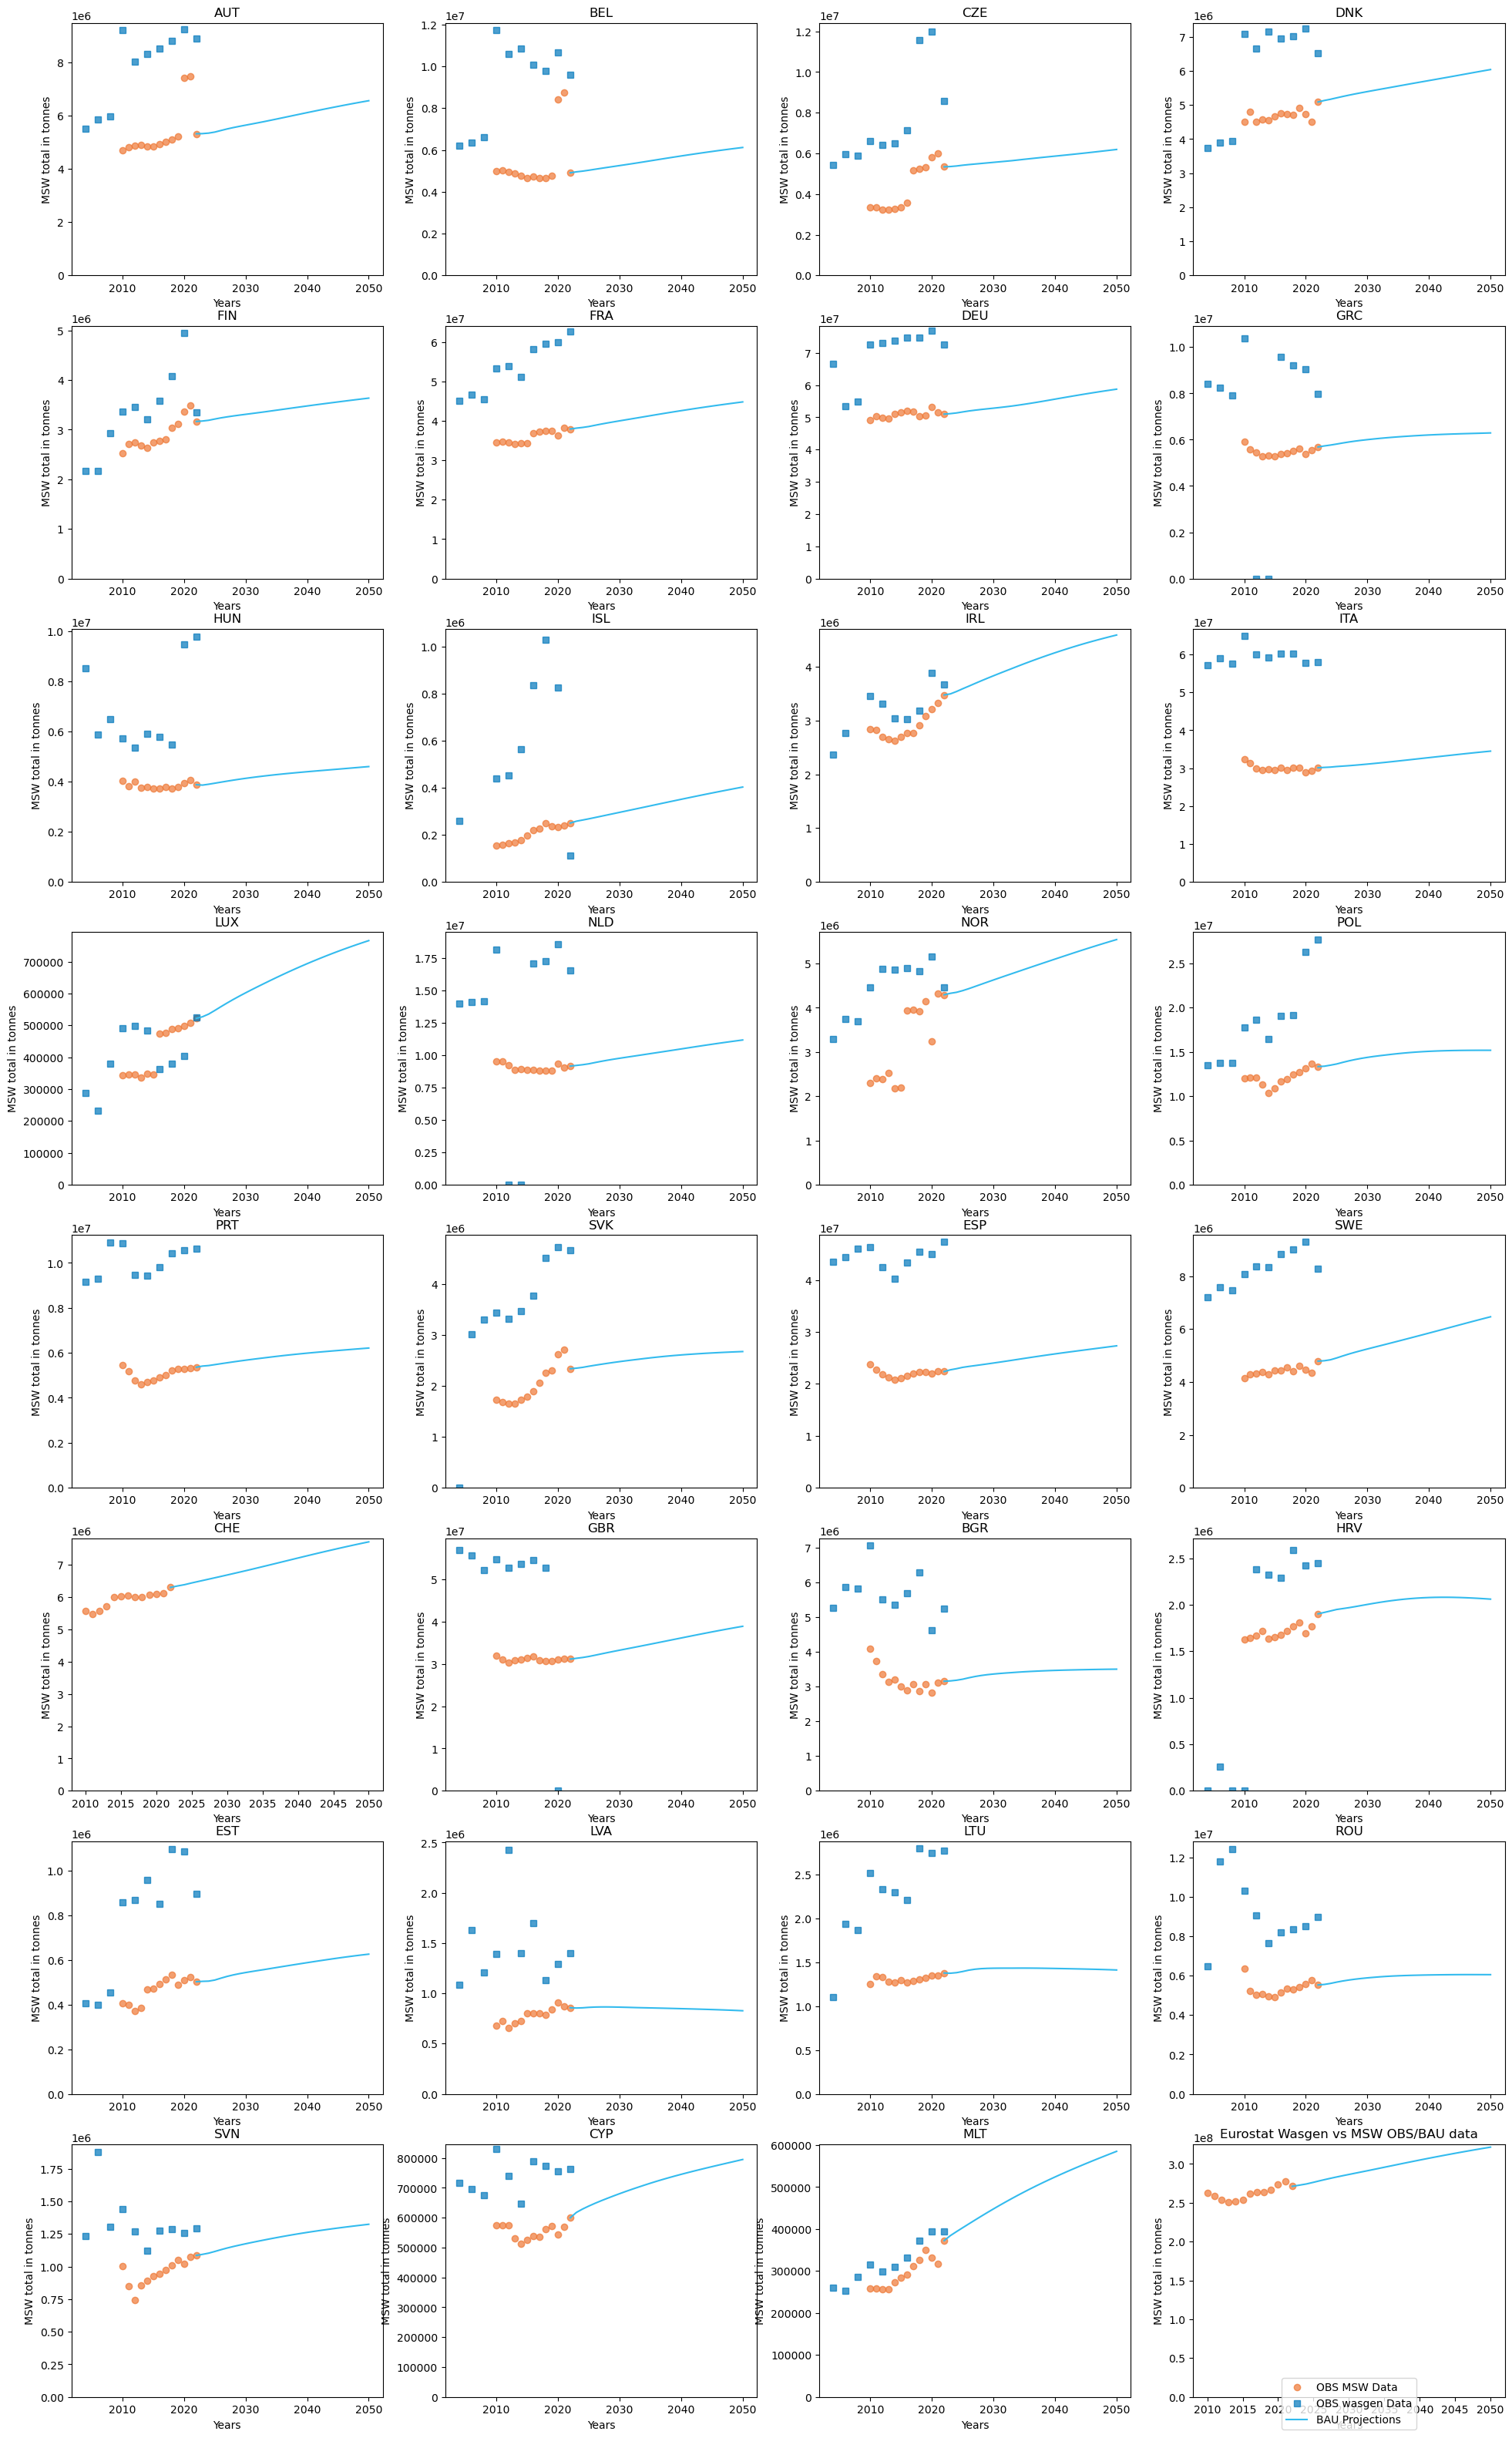

In [58]:
figure, axes = plt.subplots(8,4, figsize=(24, 40))
axes=axes.flatten()
i = 0
for country in msw_data_total_plot['LOCATION'].unique():
    reg_data_1 = msw_data_total_plot.loc[msw_data_total_plot['LOCATION'] == country]
    reg_data_2 = msw_wf_comp_total.loc[msw_wf_comp_total['NUTS_code'] == country]
    axes[i].plot()
    
    axes[i].plot(reg_data_1.loc[reg_data_1['TIME'] <= 2022]['TIME'],
                reg_data_1.loc[reg_data_1['TIME'] <= 2022]['MSW_GEN_T'],
                'o', label='OBS MSW Data', color='#EE7733', alpha = 0.7)

    axes[i].plot(reg_data_2.loc[reg_data_2['TIME_PERIOD'] <= 2022]['TIME_PERIOD'],
                reg_data_2.loc[reg_data_2['TIME_PERIOD'] <= 2022]['MSW Total'],
                's', label='OBS wasgen Data', color='#0077BB', alpha=0.7)

    x = np.arange(2022, 2051)
    axes[i].plot(x, reg_data_1['MSW_GEN_T'].loc[reg_data_1['TIME'].isin(x)],
                '-', label='BAU Projections', color= '#33BBEE')
    axes[i].set_ylim(0)
    axes[i].set_xlabel('Years')
    axes[i].set_ylabel('MSW total in tonnes')
    axes[i].set_title(country)
    i=i+1

plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15))
plt.title('Eurostat Wasgen vs MSW OBS/BAU data')
plt.show()

### Plot 2: Eurostat was gen totals vs wasmun (MSW) totals vs country_sample_total: Austria

In [67]:
msw_wf_comp_total_exmin_aut = msw_wf_comp_total_exmin.loc[msw_wf_comp_total_exmin['NUTS_code'] == 'AUT']

In [88]:
msw_aut = msw_data_total_plot.loc[msw_data_total_plot['LOCATION']=='AUT']

In [76]:
msw_sample_ref = msw_sample.loc[msw_sample['scenario']=='reference']

In [75]:
msw_sample['scenario'].unique()

array(['counterfactual', 'reference', 'policy', 'narrow', 'slow', 'close',
       'MFRappl', 'circular', 'all'], dtype=object)

In [80]:
msw_sample_ref = msw_sample_ref.groupby(['country', 'region', 'sector', 'wregion', 'year', 'urt',
       'activity'], as_index=False)['perc'].sum().reset_index()

In [82]:
msw_sample_ref = msw_sample_ref.groupby(['country', 'region', 'wregion', 'year'], as_index=False)['activity'].sum().reset_index()

In [ ]:
msw_sample_ref['activity']*=1000000

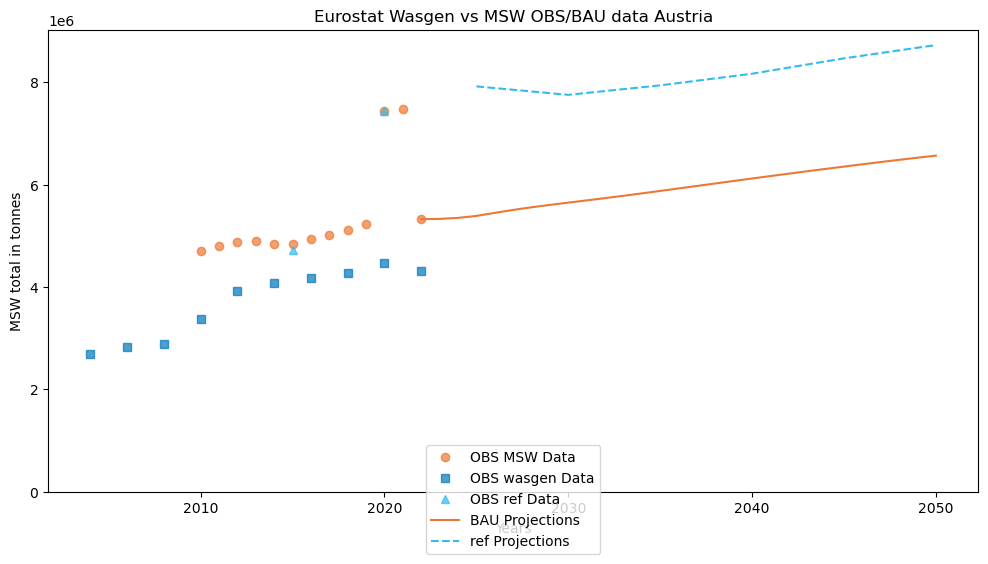

In [92]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(msw_aut.loc[msw_aut['TIME'] <= 2022]['TIME'],
    msw_aut.loc[msw_aut['TIME'] <= 2022]['MSW_GEN_T'],
    'o', label='OBS MSW Data', color='#EE7733', alpha=0.7)
ax.plot(msw_wf_comp_total_exmin_aut.loc[msw_wf_comp_total_exmin_aut['TIME_PERIOD'] <= 2022]['TIME_PERIOD'],
                msw_wf_comp_total_exmin_aut.loc[msw_wf_comp_total_exmin_aut['TIME_PERIOD'] <= 2022]['MSW Total'],
                's', label='OBS wasgen Data', color='#0077BB', alpha=0.7)
ax.plot(msw_sample_ref.loc[msw_sample_ref['year']<=2022]['year'],
         msw_sample_ref.loc[msw_sample_ref['year']<=2022]['activity'],
         '^', label='OBS ref Data', color= '#33BBEE', alpha=0.7)

x = np.arange(2022, 2051)
ax.plot(x, msw_aut['MSW_GEN_T'].loc[msw_aut['TIME'].isin(x)],
                '-', label='BAU Projections',color='#EE7733')
ax.plot(msw_sample_ref.loc[msw_sample_ref['year']>2022]['year'], msw_sample_ref.loc[msw_sample_ref['year']>2022]['activity'],
                '--', label='ref Projections',color='#33BBEE')

ax.set_ylim(0)
ax.set_xlabel('Years')
ax.set_ylabel('MSW total in tonnes')
ax.set_title(country)
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15))
plt.title('Eurostat Wasgen vs MSW OBS/BAU data Austria')
plt.show()


## Waste Fraction composition

### Plot 3: Eurostat wasgen composition timeseries trends per country 

In [21]:
msw_wf_comp_exmin = msw_wf_comp.loc[~(msw_wf_comp['category code'].isin(['W12-13','W077_08', 'W01-05','W11']))]

In [47]:
msw_wf_comp_exmin['LOCATION'].unique()

array(['AUT', 'BEL', 'BGR', 'CYP', 'CZE', 'DEU', 'DNK', 'EST', 'GRC',
       'ESP', 'FIN', 'FRA', 'HRV', 'HUN', 'IRL', 'ISL', 'ITA', 'LTU',
       'LUX', 'LVA', 'MLT', 'NLD', 'NOR', 'POL', 'PRT', 'ROU', 'SWE',
       'SVN', 'SVK', 'GBR'], dtype=object)

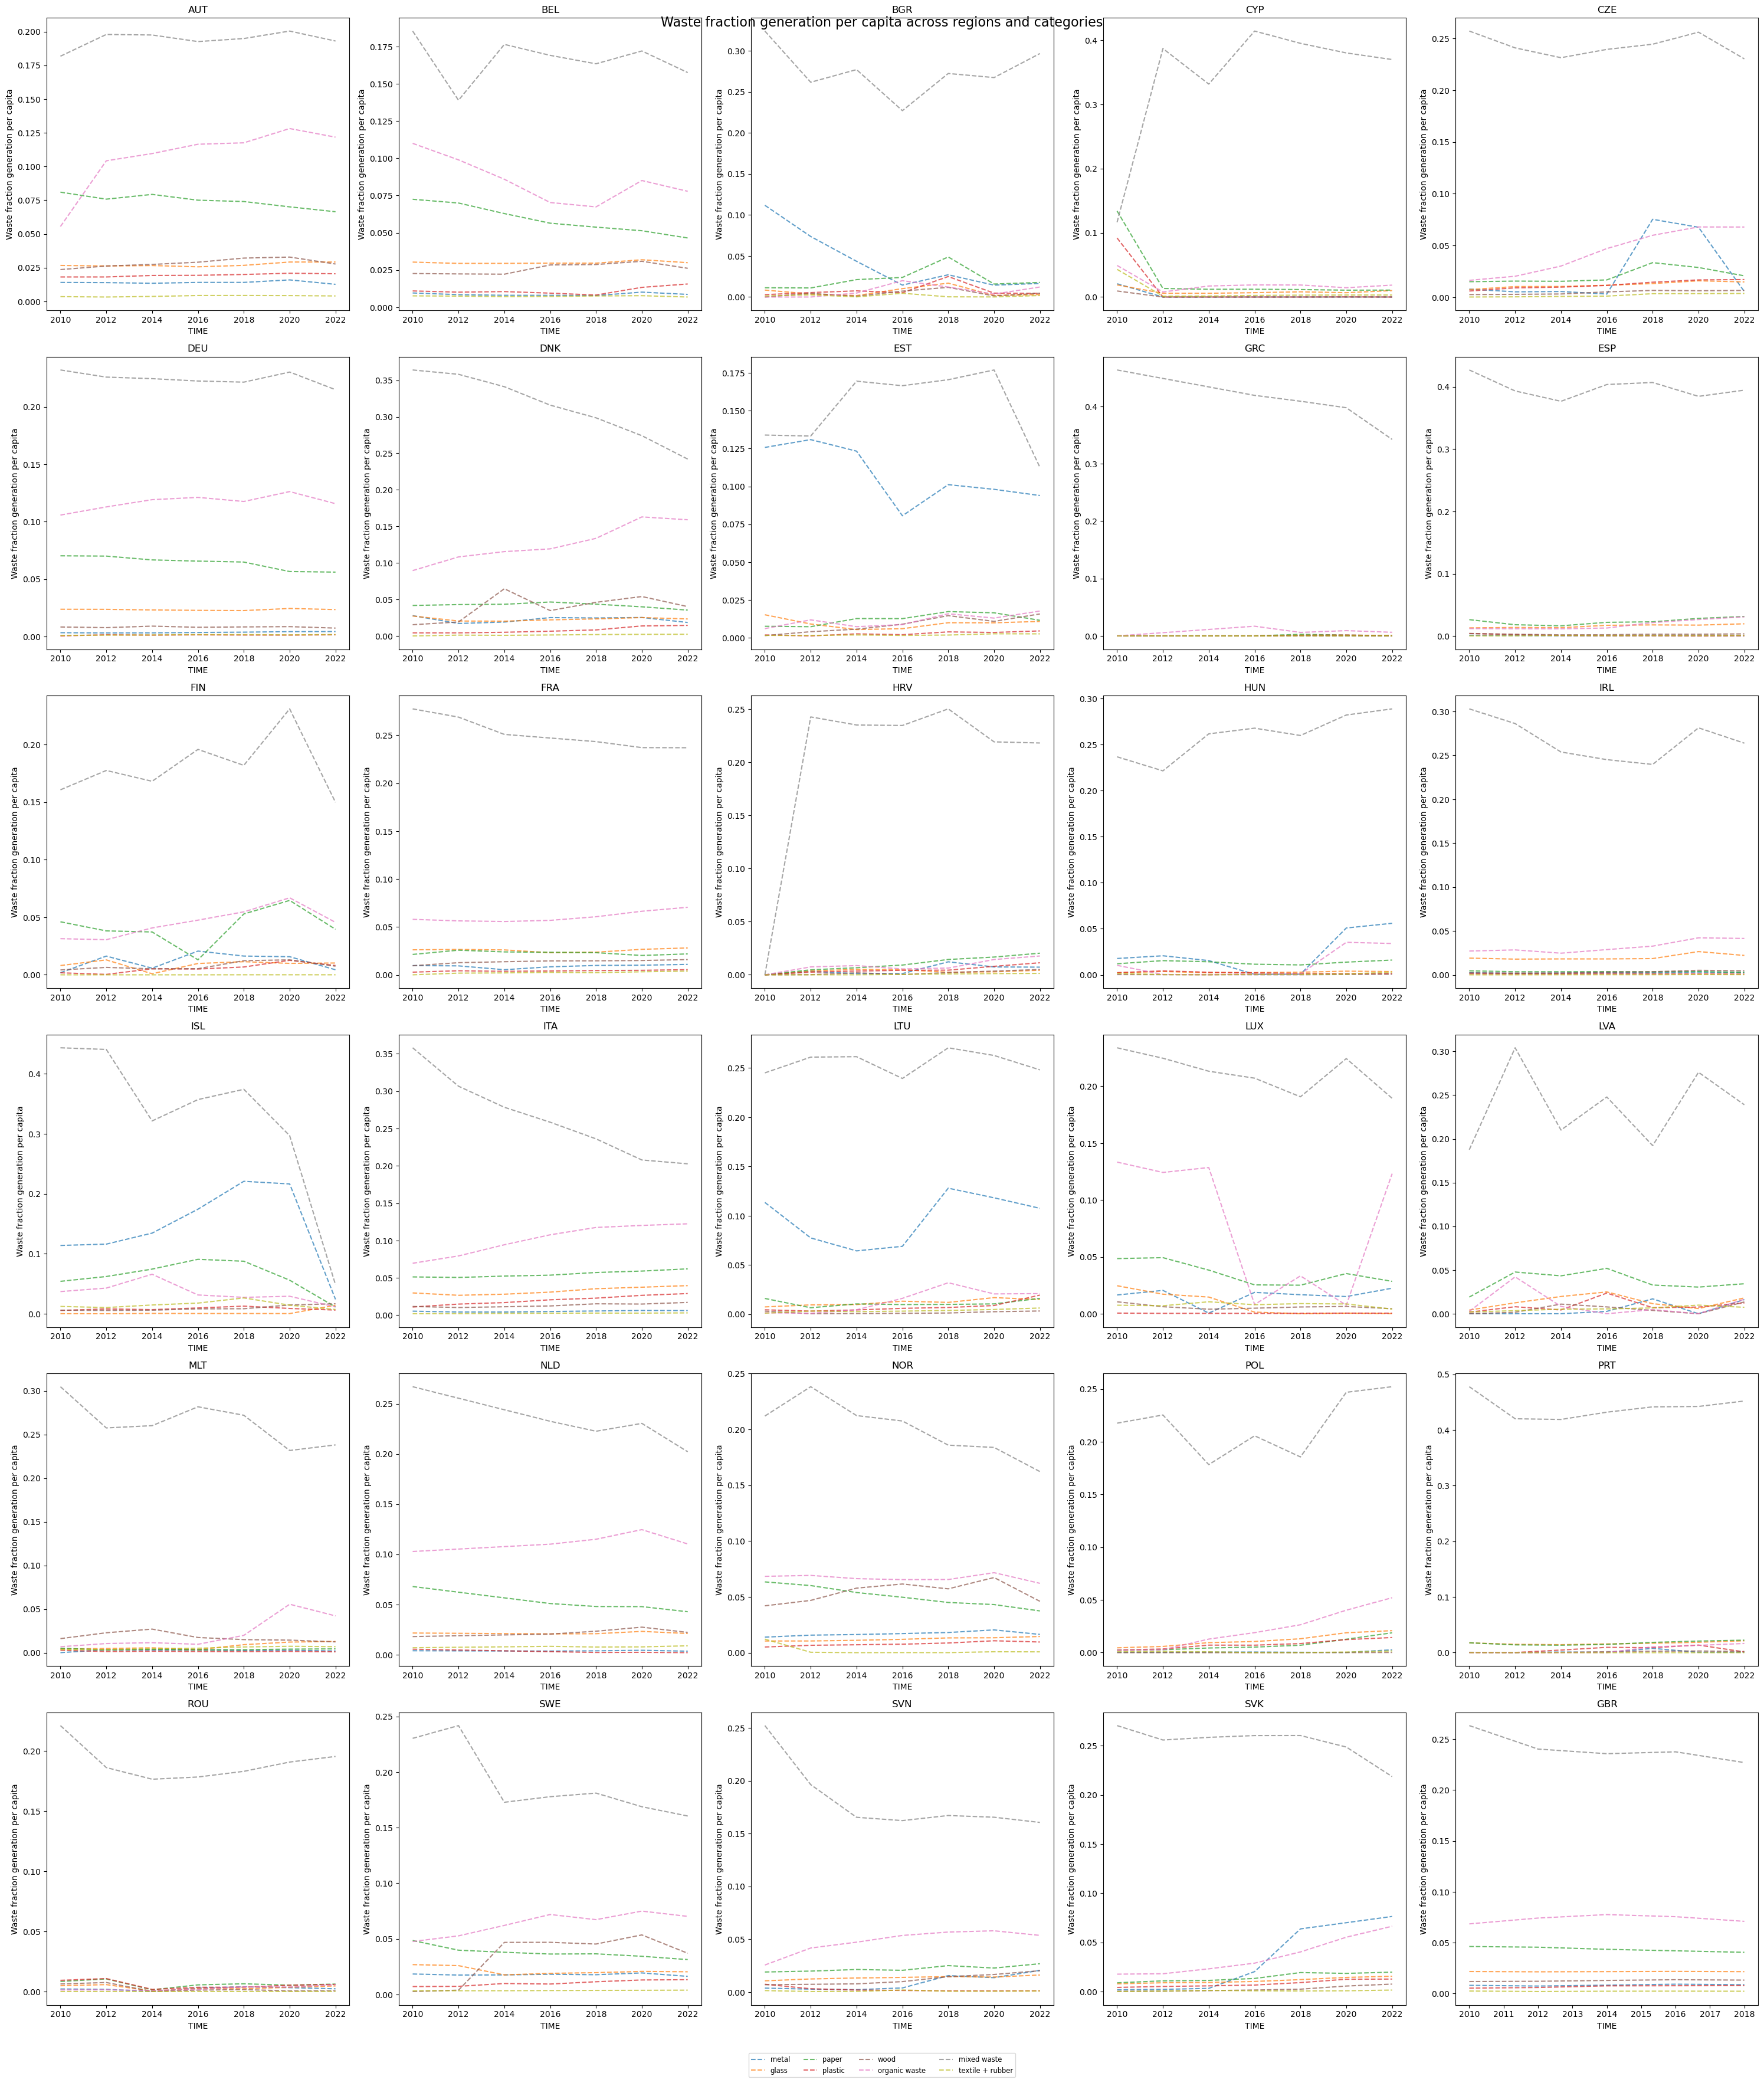

In [64]:
fig, axes = plt.subplots(6, 5, figsize=(30, 35))
axes = axes.flatten()  

cmap = plt.get_cmap('tab10')
colors = {cat: cmap(i / len(msw_wf_comp_exmin['Aggregated category name'].unique())) for i, cat in enumerate(msw_wf_comp_exmin['Aggregated category name'].unique())}


for i, reg in enumerate(msw_wf_comp_exmin['LOCATION'].unique()):
    reg_data = msw_wf_comp_exmin.loc[msw_wf_comp_exmin['LOCATION'] == reg]
    for cat in reg_data['Aggregated category name'].unique():
        cat_data = reg_data.loc[reg_data['Aggregated category name'] == cat]
        axes[i].plot(cat_data['TIME'], cat_data['Waste fraction per capita'], '--', label=cat, color = colors[cat], alpha=0.7)
    axes[i].set_xlabel('TIME')
    axes[i].set_ylabel('Waste fraction generation per capita')
    axes[i].set_title(reg)
    

    # collect unique handles/labels across axes for a single bottom legend
handles = []
labels = []
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(handles, labels, loc='lower center', ncol=4, fontsize='small', bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(top=0.95, bottom=0.16)
fig.suptitle('Waste fraction generation per capita across regions and categories', fontsize=16)
fig.tight_layout()




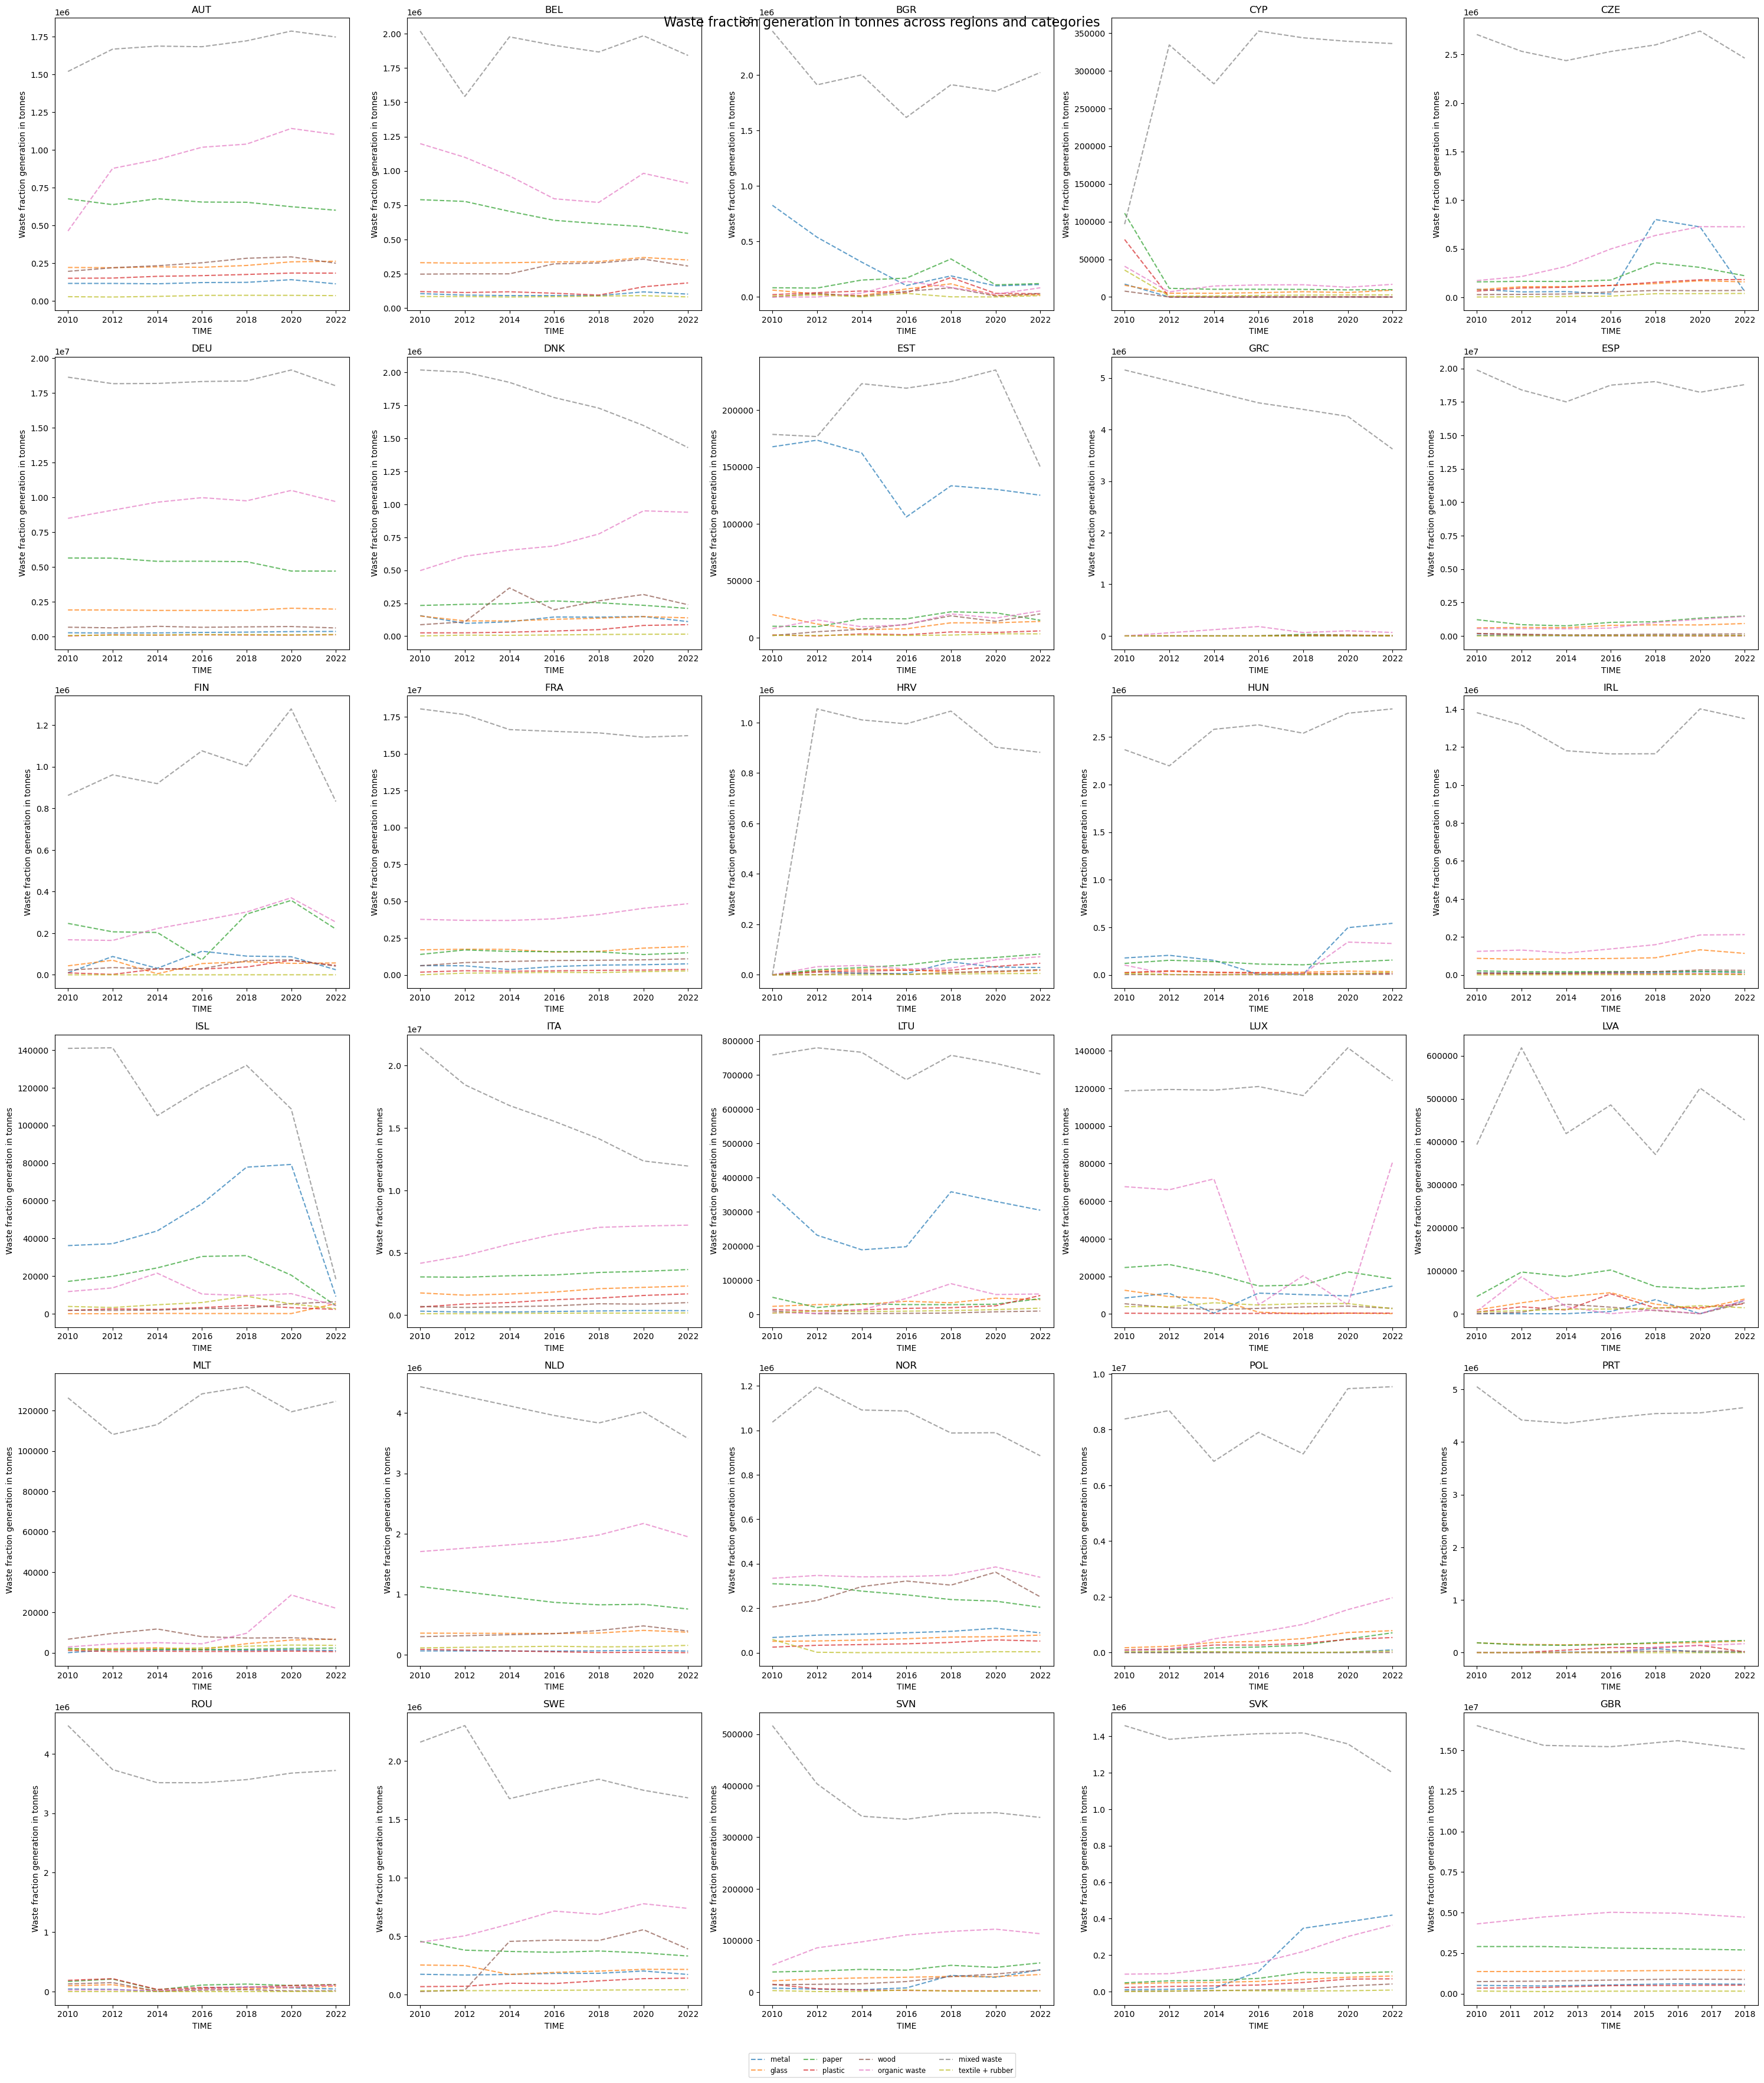

In [65]:
fig, axes = plt.subplots(6, 5, figsize=(30, 35))
axes = axes.flatten()  

cmap = plt.get_cmap('tab10')
colors = {cat: cmap(i / len(msw_wf_comp_exmin['Aggregated category name'].unique())) for i, cat in enumerate(msw_wf_comp_exmin['Aggregated category name'].unique())}


for i, reg in enumerate(msw_wf_comp_exmin['LOCATION'].unique()):
    reg_data = msw_wf_comp_exmin.loc[msw_wf_comp_exmin['LOCATION'] == reg]
    for cat in reg_data['Aggregated category name'].unique():
        cat_data = reg_data.loc[reg_data['Aggregated category name'] == cat]
        axes[i].plot(cat_data['TIME'], cat_data['OBS_VALUE'], '--', label=cat, color = colors[cat], alpha=0.7)
    axes[i].set_xlabel('TIME')
    axes[i].set_ylabel('Waste fraction generation in tonnes')
    axes[i].set_title(reg)
    

    # collect unique handles/labels across axes for a single bottom legend
handles = []
labels = []
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(handles, labels, loc='lower center', ncol=4, fontsize='small', bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(top=0.95, bottom=0.16)
fig.suptitle('Waste fraction generation in tonnes across regions and categories', fontsize=16)
fig.tight_layout()




### Plot 4: Eurostat wasgen composition vs GDP per cap

In [11]:
pop = pd.read_csv('../data/processed/eu_population_projections_cleaned.csv')
gdp = pd.read_csv('../data/processed/eu_gdp_projections_cleaned.csv')
gdp_cap = pd.read_csv('../data/processed/eu_gdp_percap_projections_cleaned.csv')

In [32]:
msw_wf_comp_exmin = pd.merge(msw_wf_comp_exmin, pop, left_on = ['TIME_PERIOD','NUTS_code'],right_on = ['TIME','LOCATION'], how ='inner')
msw_wf_comp_exmin.drop(columns=['TIME_PERIOD','NUTS_code', 'Variable'], inplace=True)

In [34]:
msw_wf_comp_exmin = pd.merge(msw_wf_comp_exmin, gdp_cap, on = ['TIME', 'LOCATION'], how ='inner')
msw_wf_comp_exmin.drop(columns=['Variable'], inplace=True)


In [35]:
msw_wf_comp_exmin.columns

Index(['unit', 'Geopolitical entity (reporting)', 'category code', 'OBS_VALUE',
       'Aggregated category name', 'LOCATION', 'TIME', 'POP', 'GDPVD_CAP'],
      dtype='object')

In [36]:
msw_wf_comp_exmin['Waste fraction per capita']= msw_wf_comp_exmin['OBS_VALUE'] / msw_wf_comp_exmin['POP']

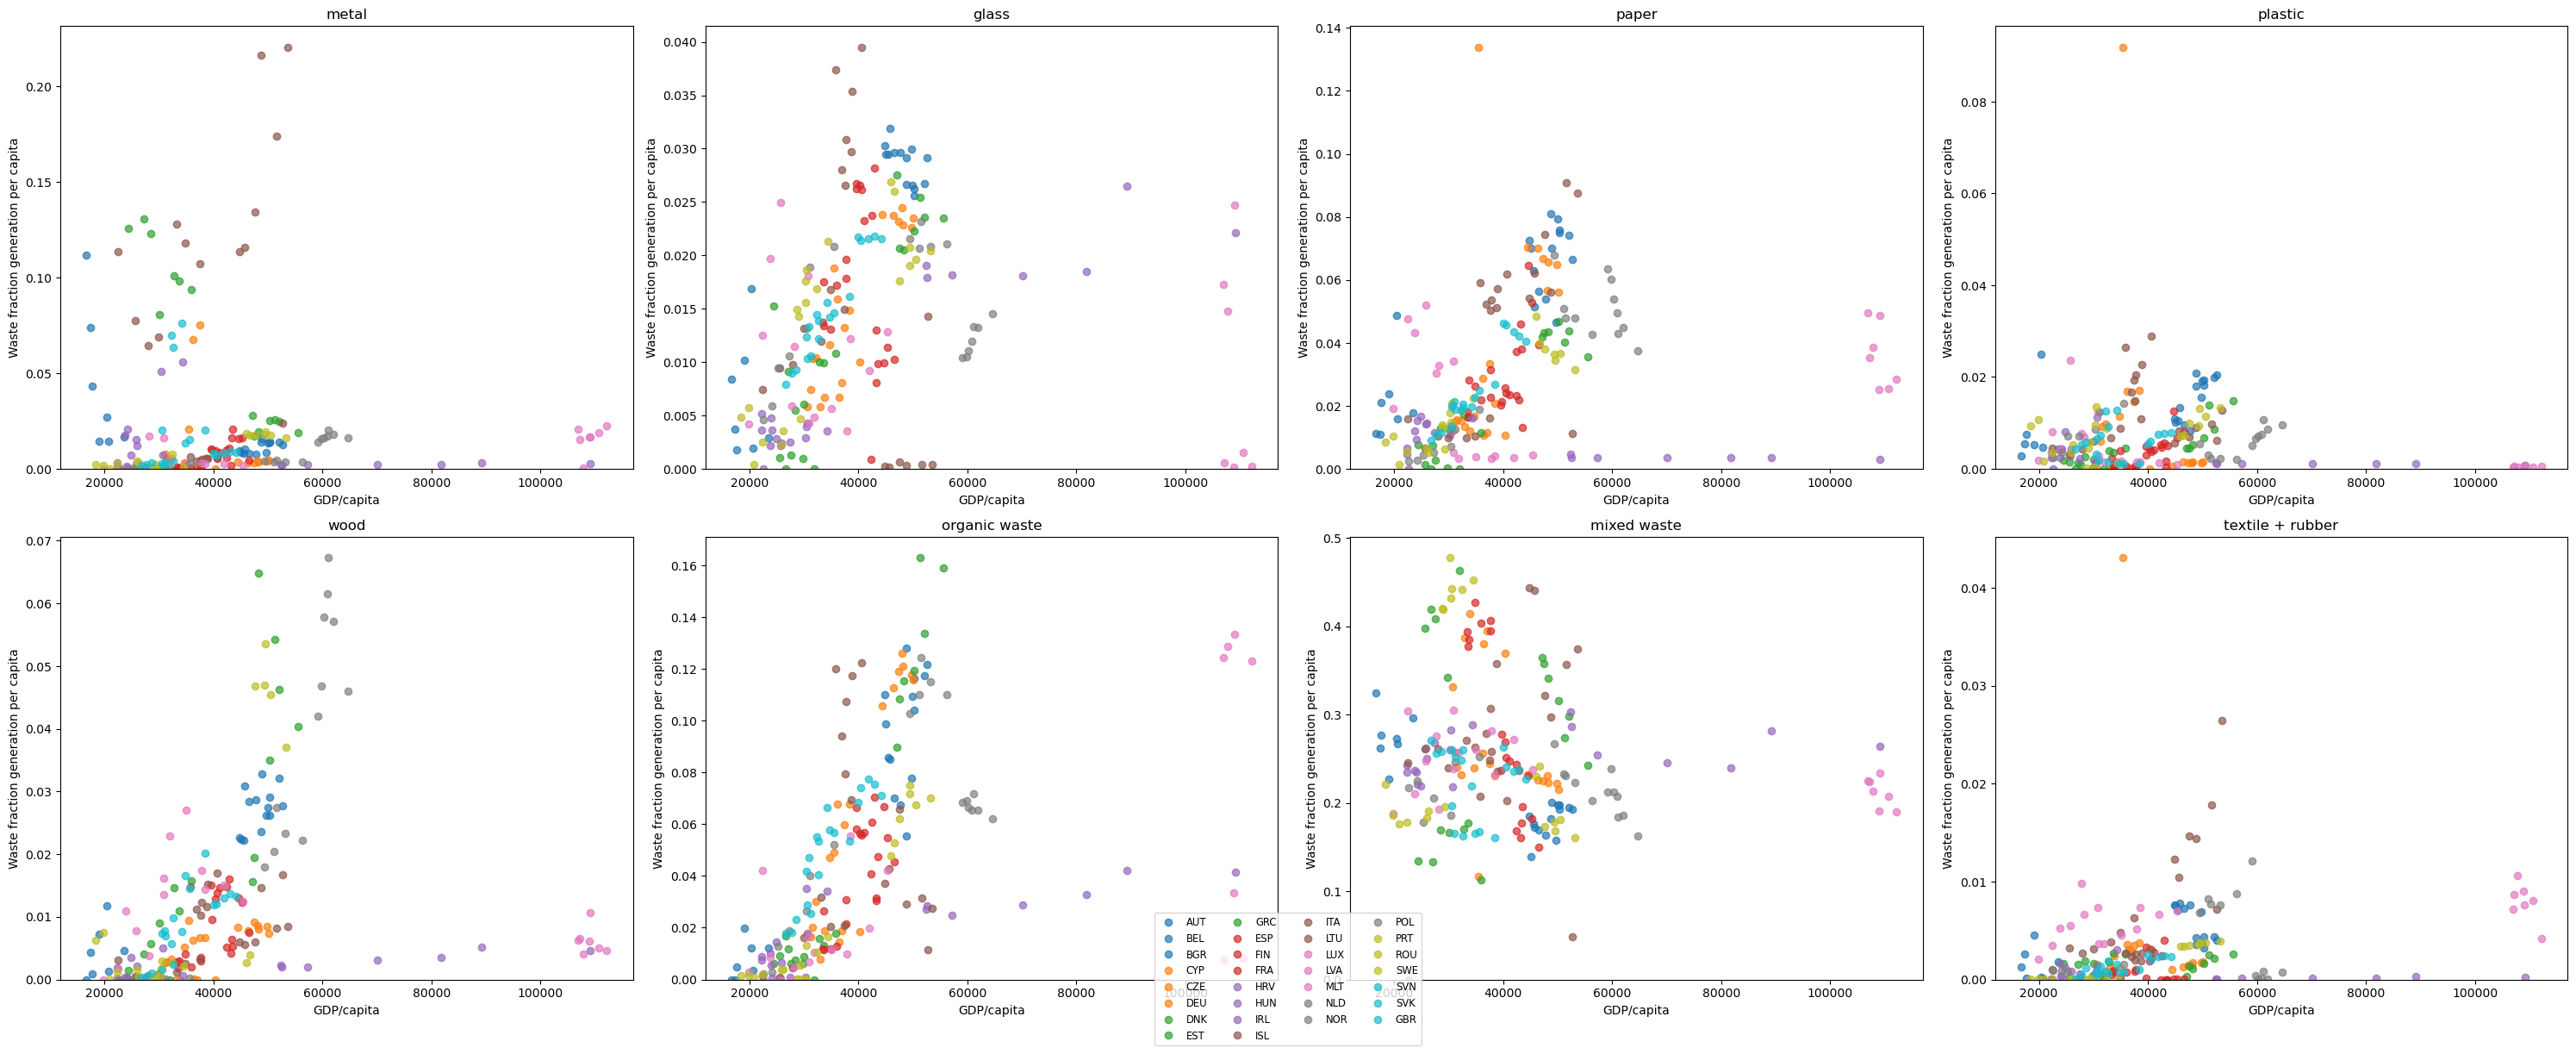

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(30, 12))
axes = axes.flatten()

cmap = plt.get_cmap('tab10')
colors = {reg: cmap(i / len(msw_wf_comp_exmin['LOCATION'].unique())) for i, reg in enumerate(msw_wf_comp_exmin['LOCATION'].unique())}

for i, cat in enumerate(msw_wf_comp_exmin['Aggregated category name'].unique()):
    cat_data = msw_wf_comp_exmin.loc[msw_wf_comp_exmin['Aggregated category name'] == cat]
    axes[i].plot()
    for reg in cat_data['LOCATION'].unique():
        reg_data = cat_data[cat_data['LOCATION'] == reg]
        axes[i].plot(reg_data['GDPVD_CAP'],
                    reg_data['Waste fraction per capita'],
                    'o', label=reg, color=colors[reg], alpha=0.7)

    axes[i].set_ylim(0)
    axes[i].set_xlabel('GDP/capita')
    axes[i].set_ylabel('Waste fraction generation per capita')
    axes[i].set_title(cat)

# collect unique handles/labels across axes for a single bottom legend
handles = []
labels = []
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(handles, labels, loc='lower center', ncol=4, fontsize='small', bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.16)
fig.tight_layout()





## Waste treatment of waste fractions country_sample

### Plot 5: Treatment trend (RCY vs INC vs Landfill) of total 

### Table 3: Category matching: Eurostat, elemental data 